# Analysis of AI's impact on students


This projects aims to answer the following questions:

- Does using AI tools improve or harm student grades?
- How does daily usage time relate to grade outcomes?
- Is there a threshold where AI usage starts hurting performance?
- Do different AI tools (ChatGPT, Copilot, Gemini) have different impacts on grades?

# 1. Set Up file structures


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())

PROJECT_ROOT = /Users/jonathanleroux/Documents/Personal_Python_Projects/AI_impact_on_students
DATA_DIR = /Users/jonathanleroux/Documents/Personal_Python_Projects/AI_impact_on_students/data
DATA_DIR exists: True


# 2. Set up imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder,StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn
from src.plot_utils import interactive_category_viewer

# 3. Import the data

In [3]:
data = pd.read_csv(DATA_DIR/'AI_Student_Life_india.csv')
data.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


# Exploratory Data Analysis

In [4]:
data.describe()

,Student_ID,Age,Daily_Usage_Hours
count,400.000000,400.000000,400.000000
mean,125.500000,19.425000,2.933750
std,87.906592,2.991948,1.589939
min,1.000000,15.000000,0.500000
25%,50.750000,17.000000,1.575000
50%,100.500000,19.500000,2.900000
75%,200.250000,22.000000,4.200000
max,300.000000,25.000000,6.000000


We have a small dataset of 400 students. Most 

They are spread out through many major cities in india

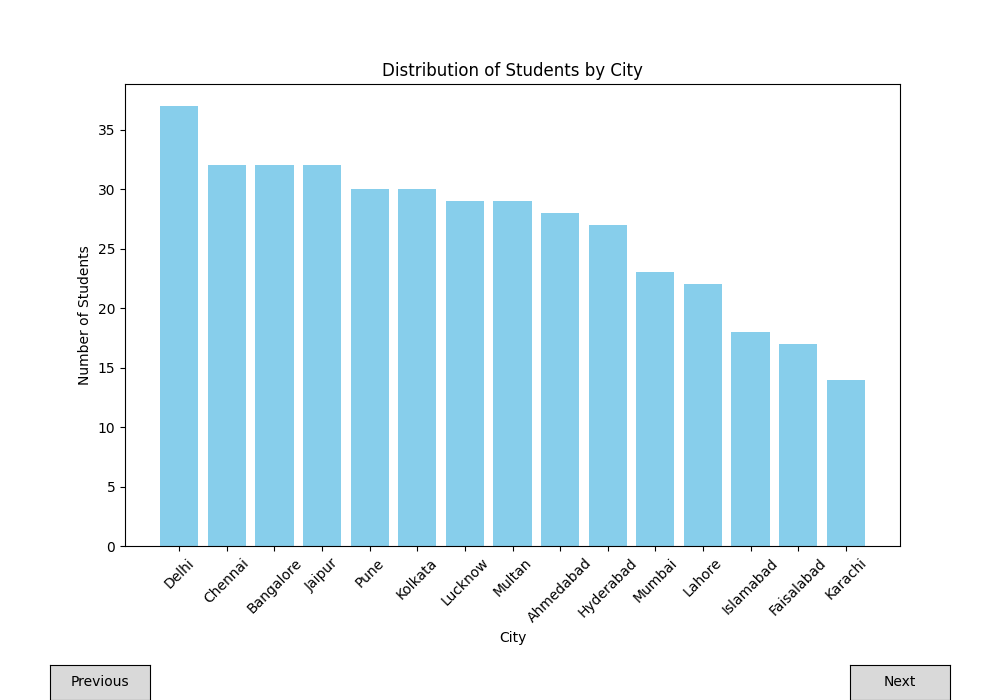

In [5]:
categories = [
    'City',
    'Gender',
    'Education_Level',
    'AI_Tool_Used',
    'Purpose',
    'Impact_on_Grades',
    'Satisfaction_Level'
]
%matplotlib widget

fig = interactive_category_viewer(data, categories)
fig

## Notes from EDA

# WRITE SOME NOTES 

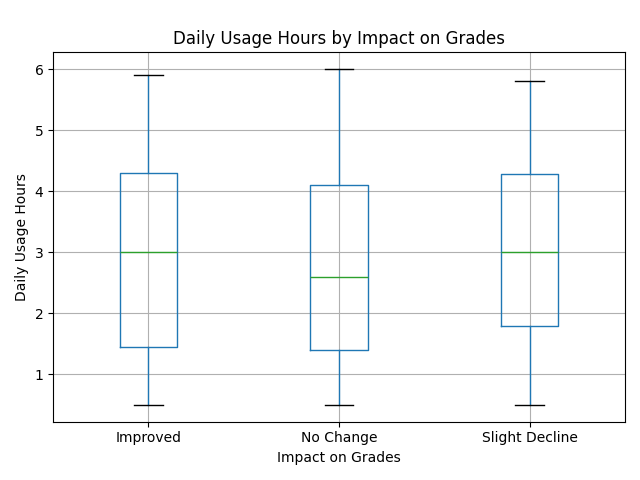

In [6]:
data.boxplot(column='Daily_Usage_Hours', by='Impact_on_Grades')
plt.title('Daily Usage Hours by Impact on Grades')
plt.suptitle('')
plt.xlabel('Impact on Grades')
plt.ylabel('Daily Usage Hours')
plt.tight_layout()
plt.show()

Interestingly people that improved their grades and slightly declined in their grades have the same median usage and upper quartile usage. Both of these are values are slightly higher than the daily usage of the people that saw no change.

# Modelling

First we model impact on grades

Second try to predict satisfaction levels

Third:
Do heavy users perform worse?
Is moderate usage optimal?
Which AI tools are most effective?
Does purpose matter more than usage time?

Fourth:

Use Kmeans to try find types of students


# Modeling: Impact on Grades

## Data preprocessing

### Encoding

In [7]:
data.isna().sum()

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

There is no missing data. So there is no need for an Imputer or dropping any records

In [8]:
target_var =data[['Impact_on_Grades']]

#when we do our preprocessing we will treat nominal variables different to categorical variables. 
#we also want to preserve relative ordering in some categorical values that have that so we further split categorical
#variables into ordinal and non-ordinal

non_ordinal_cat_vars = data[['Gender', 'Education_Level','City','AI_Tool_Used','Purpose']]
ordinal_cat_vars = data[['Satisfaction_Level']]
numeric_vars = data[['Age','Daily_Usage_Hours']]

display(target_var.describe())
display(non_ordinal_cat_vars.describe())
display(ordinal_cat_vars.describe())
display(numeric_vars.describe())


,Impact_on_Grades
count,400
unique,3
top,Improved
freq,139


,Gender,Education_Level,City,AI_Tool_Used,Purpose
count,400,400,400,400,400
unique,2,3,15,5,5
top,Male,College,Delhi,Gemini,Coding
freq,205,146,37,129,104


,Satisfaction_Level
count,400
unique,3
top,High
freq,149


,Age,Daily_Usage_Hours
count,400.000000,400.000000
mean,19.425000,2.933750
std,2.991948,1.589939
min,15.000000,0.500000
25%,17.000000,1.575000
50%,19.500000,2.900000
75%,22.000000,4.200000
max,25.000000,6.000000


### Feature scaling & encoding

In [9]:
#Making pipelines for the different type of variables
sklearn.set_config(display = 'diagram')

non_ordinal_cat_vars = ['Gender', 'Education_Level','City','AI_Tool_Used','Purpose']
ordinal_cat_vars = ['Satisfaction_Level']
numeric_attributes = ['Age','Daily_Usage_Hours']


non_ordinal_cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown = 'ignore',sparse_output=False))
])

ordinal_cat_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['Low','Medium', 'High']]))
])

numeric_pipeline= Pipeline([
    ('encoder', StandardScaler())
])

NOTE; I learned that you do not have to encode target variables for multilogistical regression

In [10]:
# combine feature pipelines
preprocessor = ColumnTransformer([
    ('non_ordinal', non_ordinal_cat_pipeline, non_ordinal_cat_vars),
    ('ordinal', ordinal_cat_pipeline, ordinal_cat_vars),
    ('numeric', numeric_pipeline, numeric_attributes)
])

# transform X
X_processed_array = preprocessor.fit_transform(data)

# make feature dataframe
X_processed = pd.DataFrame(
    X_processed_array,
    columns=preprocessor.get_feature_names_out(),
    index=data.index
)

X = X_processed 
y= data['Impact_on_Grades']
X.join(y).head()

,non_ordinal__Gender_Female,non_ordinal__Gender_Male,non_ordinal__Education_Level_College,non_ordinal__Education_Level_School,non_ordinal__Education_Level_University,non_ordinal__City_Ahmedabad,non_ordinal__City_Bangalore,non_ordinal__City_Chennai,non_ordinal__City_Delhi,non_ordinal__City_Faisalabad,...,non_ordinal__AI_Tool_Used_Notion AI,non_ordinal__Purpose_Coding,non_ordinal__Purpose_Homework,non_ordinal__Purpose_Learning,non_ordinal__Purpose_Research,non_ordinal__Purpose_Writing,ordinal__Satisfaction_Level,numeric__Age,numeric__Daily_Usage_Hours,Impact_on_Grades
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.480822,-1.154791,Slight Decline
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.527072,-0.776945,Slight Decline
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.861721,-0.902894,Improved
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.861721,0.545515,Improved
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.861721,1.427154,Slight Decline


## Train Test splitting

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  320 rows
Test set:      80 rows


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

0.3

# random forests classifier

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df.head(15))

                                    feature  importance
32               numeric__Daily_Usage_Hours    0.164375
31                             numeric__Age    0.132339
30              ordinal__Satisfaction_Level    0.067951
22         non_ordinal__AI_Tool_Used_Gemini    0.032357
20        non_ordinal__AI_Tool_Used_ChatGPT    0.031129
28            non_ordinal__Purpose_Research    0.030274
21        non_ordinal__AI_Tool_Used_Copilot    0.029976
3       non_ordinal__Education_Level_School    0.029600
2      non_ordinal__Education_Level_College    0.029184
25              non_ordinal__Purpose_Coding    0.028973
27            non_ordinal__Purpose_Learning    0.028677
29             non_ordinal__Purpose_Writing    0.028561
4   non_ordinal__Education_Level_University    0.028478
1                  non_ordinal__Gender_Male    0.027724
0                non_ordinal__Gender_Female    0.027649


In [14]:
importance_df['feature'][0:3].tolist()

['numeric__Daily_Usage_Hours', 'numeric__Age', 'ordinal__Satisfaction_Level']

In [15]:
selected_features = importance_df['feature'][0:3].tolist()

X_new = X[selected_features]
y = data['Impact_on_Grades']

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y,
    test_size=0.2,
    random_state=42,
)

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

# train
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)


0.3125

From the logistical regression model it would seem that it is impossible to predict whether ai would improve a student's grades purely based off off the factors in the dataset. 
